<h1 align="center">1 домашнее задание</h1>
<p align="center">Иван Фомин, ПАДИИ</p>

In [1]:
!python -V

Python 3.12.12


Судя по всему, это корабль


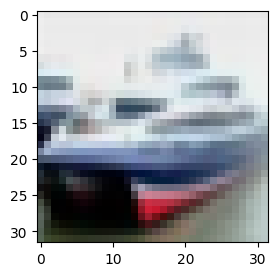

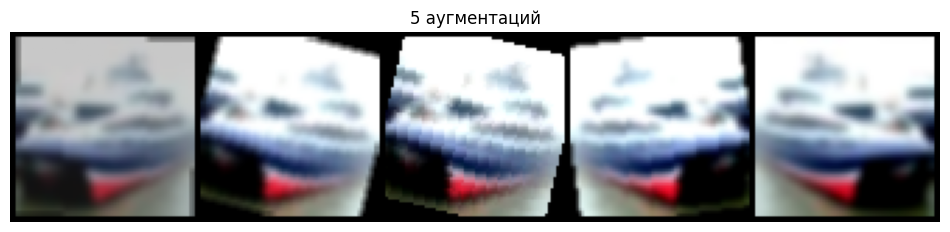

In [20]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

# Пайплайн аугментаций
transform = transforms.Compose([
    transforms.Resize(64), # В CIFAR-10 все картинки 32x32
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Меняет оттенки цветов
    transforms.RandomRotation(15),
    transforms.GaussianBlur(kernel_size=3),
    transforms.ToTensor(),
])

# Загрузка изображения из CIFAR-10
cifar_test = CIFAR10(root='./data', train=False, download=True, transform=None)
image, label = cifar_test[1]
plt.figure(figsize=(12, 3))
plt.imshow(image)
print("Судя по всему, это корабль")

# Выводим 5 аугментаций изображения
augmented = [transform(image) for _ in range(5)]
grid = make_grid(augmented, nrow=5, padding=2, normalize=True)
plt.figure(figsize=(12, 3))
plt.imshow(grid.permute(1, 2, 0))
plt.axis('off')
plt.title(f"5 аугментаций")
plt.show()

**Вывод:** из-за того, что некоторые аугментации случайно меняют изображение, на каждой из 5 итераций я получил разные результаты. Благодаря такой обработке данных обученная на них модель будет более устойчивой к переобучению, сможет увидеть, например, корабль на самых разных (даже некачественных) изображениях.